In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"  # Use double precision
import jax
import jax.numpy as jnp
import optax
import numpy as np
import time
from utils.variational_quantum_states.boltzmann_quantum_states import DeepBoltzmannQuantumState
from utils.operators import (
    build_local_longitudinal_field_ising_energy,
    build_local_parametric_hamiltonian,
    build_measurement_function,
)
from utils.tdvp import build_parametric_gradient_estimator
from utils.variational_annealer import VariationalAnnealer
from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable 
import matplotlib.gridspec as gridspec

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from scipy.stats import gaussian_kde
from sklearn.cluster import KMeans

CM = 1 / 2.54
PRX_SINGLE = 8.5 * CM  # ~3.35 in
PRX_ONEHALF = 14.0 * CM  # ~5.51 in
PRX_DOUBLE = 17.8 * CM  # ~7.01 in


def prx_figsize(width="single", aspect=1.5):
    w = {"single": PRX_SINGLE, "1.5": PRX_ONEHALF, "double": PRX_DOUBLE}[width]
    return (w, w * aspect)

plt.style.use("prx_quantum.mplstyle")

In [3]:
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm

In [4]:
prngkey = jax.random.PRNGKey(0)

num_spins = 4
dbqs_layers = [4, 2]

In [5]:
prngkey, tempkey = jax.random.split(prngkey)
J_matrix = jax.random.normal(tempkey, (num_spins, num_spins))
J_matrix = (J_matrix + J_matrix.T) / 2
J_matrix = J_matrix.at[jnp.diag_indices(num_spins)].set(0.0)
J_matrix = J_matrix / (2 * np.sqrt(num_spins))

In [6]:
# brute force solution
J_np = np.asarray(J_matrix, dtype=np.float64)  # host copy for simple numpy math
current_best_energy = float("inf")
current_best_config = None
for idx in range(2**num_spins):
    # build spin config in {-1, +1} without creating a JAX array from strings
    bits = np.array(list(np.binary_repr(idx, width=num_spins)), dtype=np.int8)
    config = (2 * bits - 1).astype(np.float64)

    # E = -1/2 sum_{ij} J_ij s_i s_j = -1/2 * s^T J s
    energy = float(config @ J_np @ config)

    if energy < current_best_energy:
        current_best_energy = energy
        current_best_config = config

print("Brute force solution:")
print("Ground state energy:", current_best_energy)
print("Ground state configuration:", current_best_config)

Brute force solution:
Ground state energy: -1.5978799007674476
Ground state configuration: [-1. -1.  1. -1.]


In [7]:
prngkey, tempkey = jax.random.split(prngkey)
vqs = DeepBoltzmannQuantumState(
    num_spins=num_spins,
    layers=dbqs_layers,
    prngkey=tempkey,
    num_samples=2**8,
    num_thermalization_steps=100,
    num_sweep_steps=10,
    num_chains=2**8,
    dtype=jnp.complex128,
    use_bias=True,
)

local_energy_z_target = build_local_longitudinal_field_ising_energy(
    J_matrix=J_matrix,
)
_local_energy_sigma_x = vqs.local_energy_sigma_x
_local_energy_sigma_y = vqs.local_energy_sigma_y
local_energy_target = lambda params, config: local_energy_z_target(
    params, config
)
local_energy_annealing = lambda params, spins: _local_energy_sigma_x(params, spins)
local_energy_catalyst= lambda params, spins: 0#_local_energy_sigma_y(params, spins)

local_hamiltonian = build_local_parametric_hamiltonian(
    local_target_hamiltonian=local_energy_target,
    local_annealing_hamiltonian=local_energy_annealing,
    local_catalyst_hamiltonian=local_energy_catalyst,
)
gradient_estimator = build_parametric_gradient_estimator(
    variational_quantum_state=vqs,
    local_hamiltonian=local_hamiltonian,
    diag_shift=1e-2,
)

optimizer = optax.sgd(0.1, momentum=0.5)
times = jnp.linspace(0, 1.0, 1000)
observables_dict = {
    "target_energy": build_measurement_function(local_energy_target, return_best=True),
    "annealing_energy": build_measurement_function(local_energy_annealing),
    "catalyst_energy": build_measurement_function(local_energy_catalyst),
}
schedule = jax.vmap(lambda t: jnp.array([t, 1 - t, t*(1-t)]))(times)
variational_annealer = VariationalAnnealer(
    variational_quantum_state=vqs,
    parametric_gradient_estimator=gradient_estimator,
    optimizer=optimizer,
    annealing_schedule=schedule,
    persistent_chains=True,
    observables_dict=observables_dict,
    num_warmup_steps=1,
    num_updates_per_step=1,
    num_finetuning_steps=1,
    use_tqdm=True,
    log_every=1,
    log_params=True,
)

data = variational_annealer.run(
    prngkey,
)

data = {key: np.array(value) for key, value in data.items()}

100%|██████████| 1000/1000 [00:43<00:00, 22.85it/s]


In [8]:
data["target_energy"][-1]

array([-1.59787990e+00,  4.93038066e-32, -1.59787990e+00,  1.00000000e+00,
        1.00000000e+00, -1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
       -1.00000000e+00, -1.00000000e+00, -1.00000000e+00,  1.00000000e+00,
        1.00000000e+00])

In [9]:
data["magnetizations"][-1]

array([-0.0390625, -0.0390625,  0.0390625, -0.0390625, -0.0234375,
        0.140625 ,  0.1328125,  0.0078125,  0.       , -0.1640625])

In [10]:
params_trajectory = data["params"]

In [12]:
@jax.jit
def loss(params, s):
    tempkey = jax.random.PRNGKey(0)
    samples, _ = vqs.generate_samples(tempkey, params)
    loss_value = (
        s * observables_dict["target_energy"](params, samples)[0]
        + (1 - s) * observables_dict["annealing_energy"](params, samples)[0]
        + s* (1 - s) * observables_dict["catalyst_energy"](params, samples)[0]
    )
    return (loss_value).real

In [13]:
W_orig = np.asarray(params_trajectory)
assert W_orig.ndim == 2, "params_trajectory must be [T,P]"
T_full, P = W_orig.shape

if np.iscomplexobj(W_orig):
    W_real = np.concatenate([W_orig.real, W_orig.imag], axis=1)
    to_original = lambda r: r[:P] + 1j * r[P:]
else:
    W_real = W_orig
    to_original = lambda r: r

# w_final_real = W_real[-1]
# w_final_real = W_real[0]
w_final_real = np.mean(W_real, axis=0)
centered_full = W_real - w_final_real

_, _, Vt = np.linalg.svd(centered_full, full_matrices=False)
d1 = Vt[0]
d2 = Vt[1] if Vt.shape[0] > 1 else np.eye(Vt.shape[1])[(np.argmax(np.abs(Vt[0])) + 1) % Vt.shape[1]]

min_extent = 1e-1
pad_frac = 0.5

alphas_full = (W_real - w_final_real) @ d1
betas_full = (W_real - w_final_real) @ d2
a_min, a_max = float(alphas_full.min()), float(alphas_full.max())
b_min, b_max = float(betas_full.min()), float(betas_full.max())
a_span = max(a_max - a_min, min_extent)
b_span = max(b_max - b_min, min_extent)
a_min_pad, a_max_pad = a_min - pad_frac * a_span, a_max + pad_frac * a_span
b_min_pad, b_max_pad = b_min - pad_frac * b_span, b_max + pad_frac * b_span

num_points = 25

a_lin = np.linspace(a_min_pad, a_max_pad, num_points)
b_lin = np.linspace(b_min_pad, b_max_pad, num_points)
A, B = np.meshgrid(a_lin, b_lin)
grid_plane = w_final_real[None, :] + A.reshape(-1, 1) * d1 + B.reshape(-1, 1) * d2

def foo(s):
    s_clamped = float(np.clip(s, 0.0, 1.0))
    step_idx = int(round(s_clamped * (T_full - 1)))
    W_trunc_real = W_real[:step_idx+1]
    losses = [loss(to_original(g), s_clamped) for g in grid_plane]
    loss_surface = np.array(losses).reshape(A.shape)
    alphas_trunc = (W_trunc_real - w_final_real) @ d1
    betas_trunc  = (W_trunc_real - w_final_real) @ d2
    traj_xy = np.stack([alphas_trunc, betas_trunc], axis=1)
    return loss_surface, traj_xy



In [14]:
anneal_values = [0.0, 0.5, 0.6, 0.7, 0.8, 1.0]
# anneal_values = [0.0, 0.7, 1.0]
figsize_per_row = 1.7
show_levels = 55

In [15]:
anneals = [0, 0.5, 0.6, 0.7, 0.85, 1.0]
num_levels = show_levels
surfaces = []
trajs = []
mins = []
maxs = []
for s in anneals:
    ls, tr = foo(s)
    surfaces.append(ls)
    trajs.append(tr)
    mins.append(np.nanmin(ls))
    maxs.append(np.nanmax(ls))
vmin = float(np.nanmin(mins))
vmax = float(np.nanmax(maxs))
sorted_extremes = np.sort(np.array((mins, maxs)), axis=None)

In [16]:
nums_points = [3, 3, 5, 5, 7, 7, 7, 5, 5, 3, 3]
levels = np.concatenate(
    [np.linspace(sorted_extremes[i], sorted_extremes[i + 1], nums_points[i])[:-1] for i in range(len(sorted_extremes) - 1)]
)
line_levels = levels

In [17]:
len(sorted_extremes) - 1

11

In [18]:
n_rows = len(anneals)

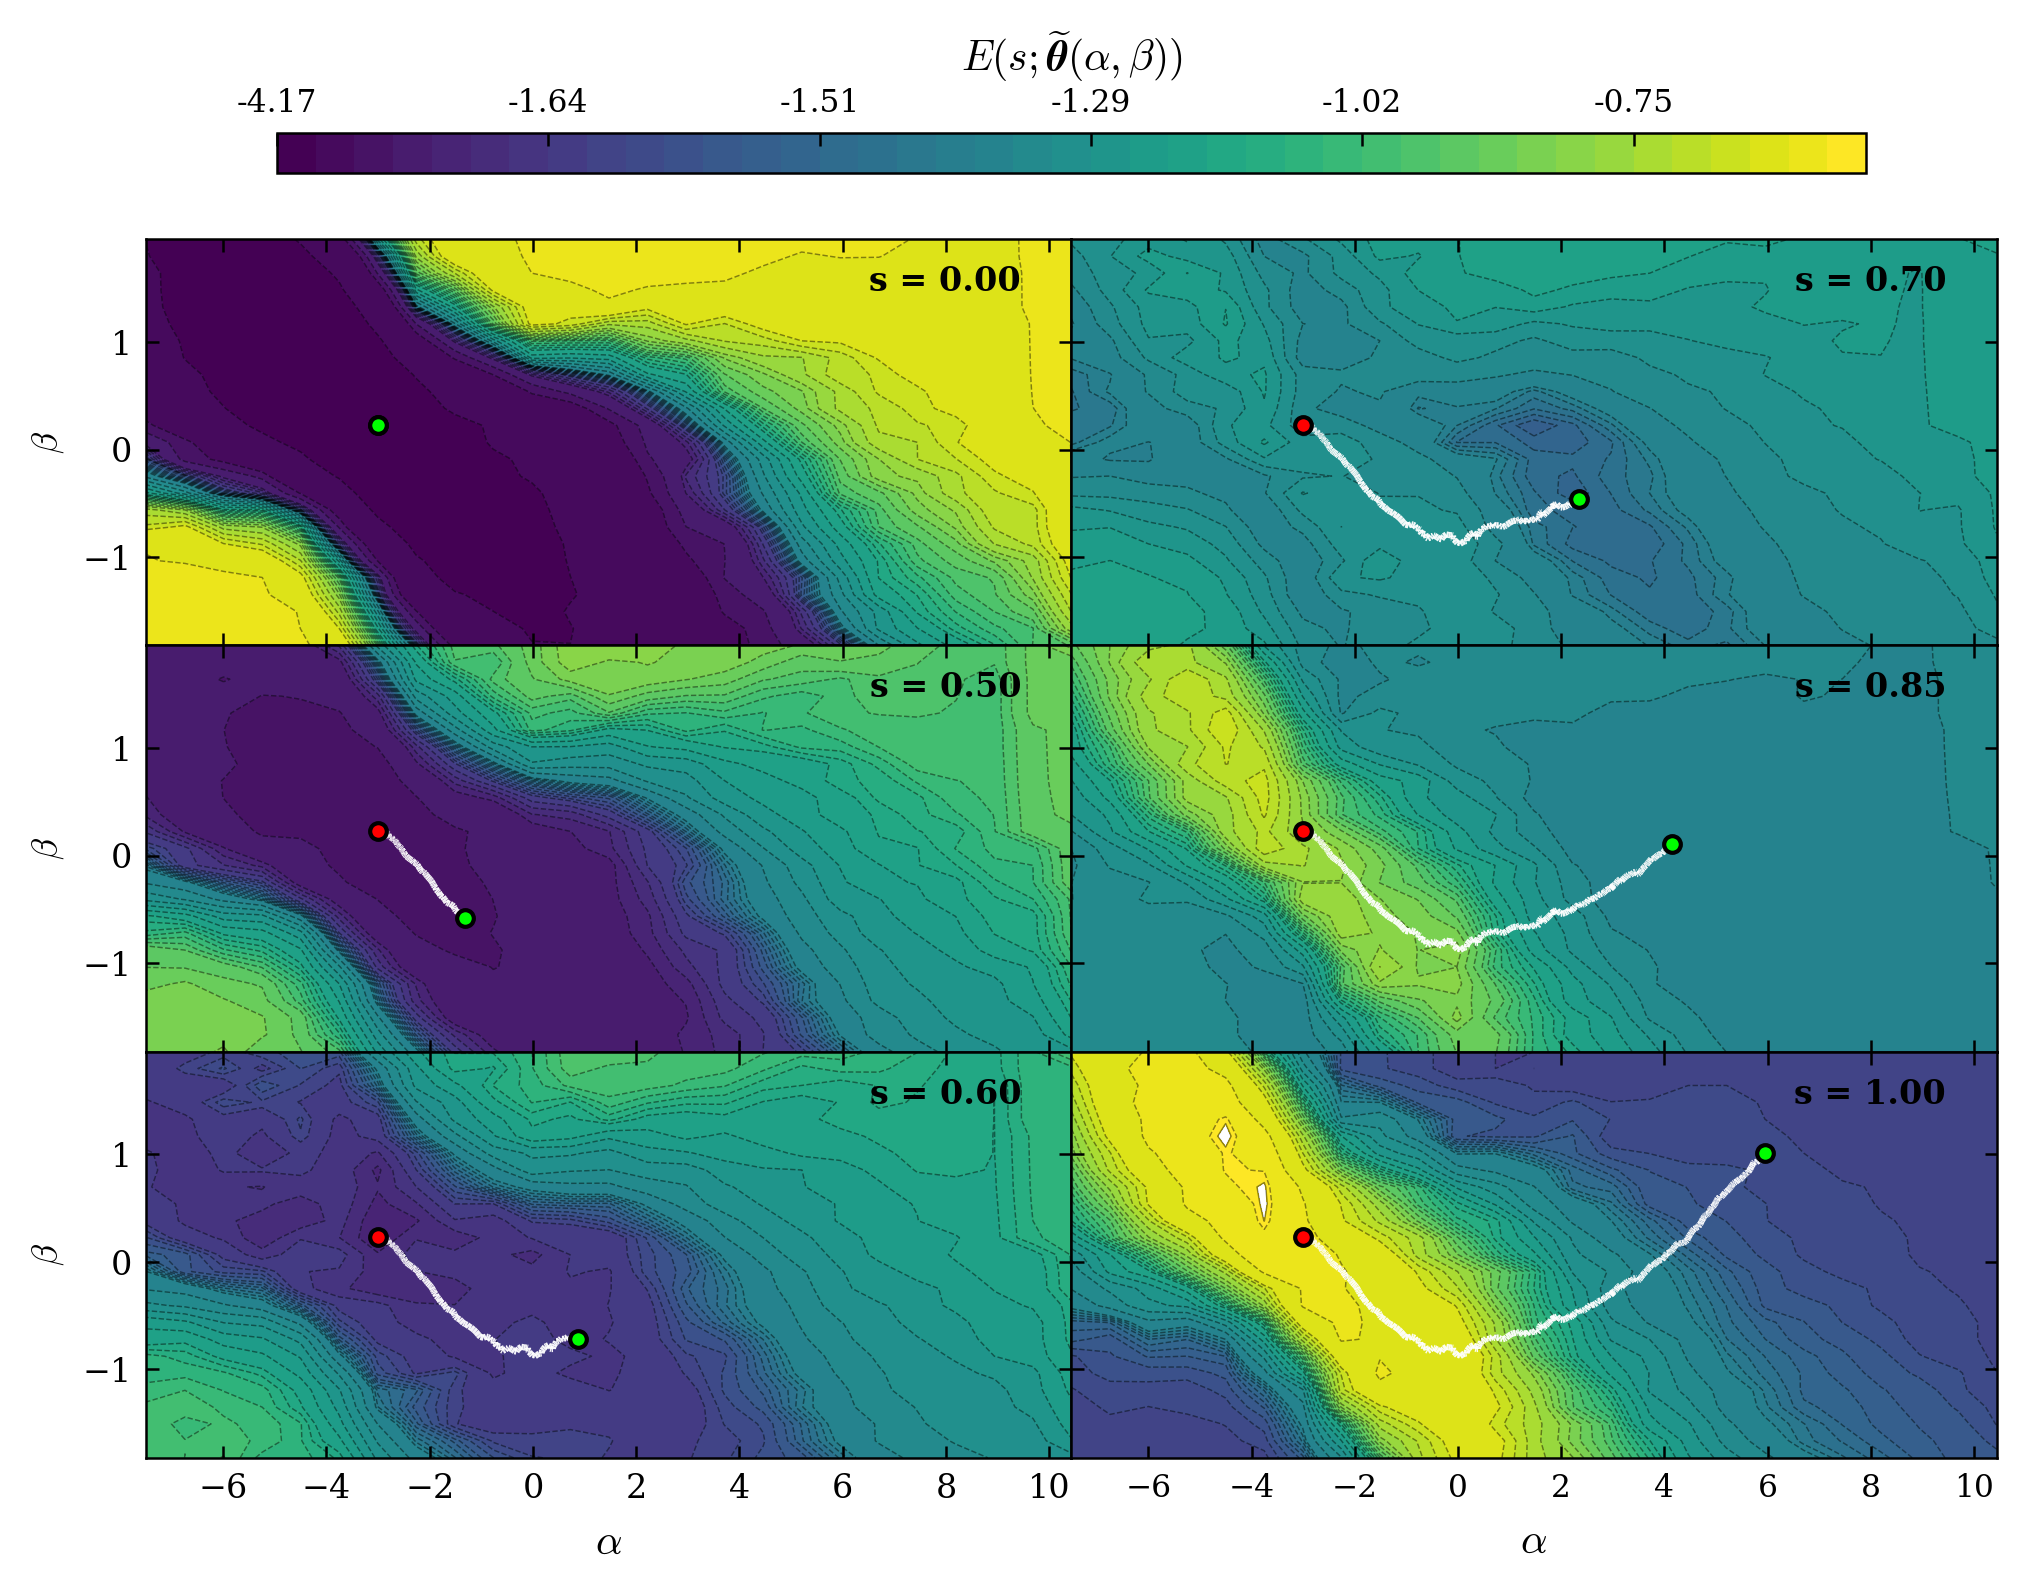

In [19]:
plt.rcParams["figure.figsize"] = prx_figsize("double", aspect=0.7)
fig, axes = plt.subplots(n_rows//2, 2, sharex=True, sharey=True,
                         gridspec_kw={'hspace': 0, 'wspace': 0})
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# Remove outer margins and enforce zero spacing
fig.subplots_adjust(left=0.10, right=0.98, top=0.98, bottom=0.08, hspace=0, wspace=0)

cf0 = None
s_labels = []
for row, s in enumerate(anneals[3:]):
    ax_land = axes[row, 1]
    loss_surface = surfaces[row+3]
    traj_xy = trajs[row+3]

    # Hide x tick labels for all but bottom row (prevents label padding between rows)
    if row < n_rows - 1:
        ax_land.tick_params(labelbottom=False)

    # Loss landscape with shared levels
    cf = ax_land.contourf(
        A, B, loss_surface,
        levels=levels,
        cmap="viridis",
        norm=BoundaryNorm(levels, ncolors=256, clip=True),
    )
    ax_land.contour(A, B, loss_surface, levels=line_levels, colors="k", linewidths=0.35, alpha=0.45)
    ax_land.set_xlabel(r"$\alpha$", fontsize=10)
    # ax_land.set_ylabel(r"$\beta$", fontsize=10)
    # # ticks on the right side
    # ax_land.tick_params(axis="both", which="major", labelsize=8)
    # ax_land.yaxis.set_label_position("right")
    # ax_land.yaxis.tick_right()
    # bottom row: show x ticks
    # if row == n_rows - 1:
    #     ax_land.tick_params(labelbottom=True)
    #     ax_land.set_xlabel(r"$\alpha$", fontsize=10)

    # Trajectory
    if traj_xy.shape[0] > 1:
        segs = np.stack([traj_xy[:-1], traj_xy[1:]], axis=1)
        lc = LineCollection(segs, colors="white", linewidth=1.5, alpha=0.95)
        ax_land.add_collection(lc)
    ax_land.scatter(traj_xy[0, 0], traj_xy[0, 1], c="red", edgecolor="k", label=r"$\widetilde{\theta}(0)$", zorder=3)
    ax_land.scatter(traj_xy[-1, 0], traj_xy[-1, 1], c="lime", edgecolor="k", label=r"$\widetilde{\theta}(s)$", zorder=3)

    if cf0 is None:
        cf0 = cf
    s_labels.append((float(np.clip(s, 0.0, 1.0)), ax_land))
for row, s in enumerate(anneals[:3]):
    ax_land = axes[row, 0]
    loss_surface = surfaces[row]
    traj_xy = trajs[row]

    # Hide x tick labels for all but bottom row (prevents label padding between rows)
    if row < n_rows - 1:
        ax_land.tick_params(labelbottom=False)

    # Loss landscape with shared levels
    cf = ax_land.contourf(
        A, B, loss_surface,
        levels=levels,
        cmap="viridis",
        norm=BoundaryNorm(levels, ncolors=256, clip=True),
    )
    ax_land.contour(A, B, loss_surface, levels=line_levels, colors="k", linewidths=0.35, alpha=0.45)
    ax_land.set_xlabel(r"$\alpha$", fontsize=10)
    ax_land.set_ylabel(r"$\beta$")
    ax_land.tick_params(axis="both", which="major", labelsize=8)

    # Trajectory
    if traj_xy.shape[0] > 1:
        segs = np.stack([traj_xy[:-1], traj_xy[1:]], axis=1)
        lc = LineCollection(segs, colors="white", linewidth=1.5, alpha=0.95)
        ax_land.add_collection(lc)
    ax_land.scatter(traj_xy[0, 0], traj_xy[0, 1], c="red", edgecolor="k", label=r"$\widetilde{\theta}(0)$", zorder=3)
    ax_land.scatter(traj_xy[-1, 0], traj_xy[-1, 1], c="lime", edgecolor="k", label=r"$\widetilde{\theta}(s)$", zorder=3)

    if cf0 is None:
        cf0 = cf
    s_labels.append((float(np.clip(s, 0.0, 1.0)), ax_land))

for col in range(axes.shape[1]):
    axes[-1, col].tick_params(axis='x', bottom=True, labelbottom=True)


# Shared colorbar spanning all rows (horizontal, top side)
# Round to two digits after comma
land_axes = axes.ravel().tolist()
cbar = fig.colorbar(cf0, ax=land_axes, orientation="horizontal", location="top", fraction=0.03, aspect=40, spacing="uniform")  # <- use cf0, not cax
cbar.ax.tick_params()
cbar.set_ticks(levels[::max(1, len(levels)//6)])
cbar.ax.minorticks_off()
cbar.ax.set_xticklabels([f"{tick:.2f}" for tick in cbar.ax.get_xticks()])
cbar.set_label(r"$E(s;\widetilde{{\boldsymbol{\theta}}}(\alpha,\beta))$", fontsize=10)

# Row labels and title
fig.canvas.draw()
for s_val, ax_l in s_labels:
    pl = ax_l.get_position()
    x_right = pl.x0 + pl.width - 0.06 # + 0.07 
    y_top = pl.y0 + pl.height - 0.04
    fig.text(x_right, y_top, f"s = {s_val:.2f}", ha="center", va="bottom", fontweight="bold")

# pl = s_labels[0][1].get_position()
# x_center = pl.x0 + pl.width / 2
# y_top = pl.y0 + pl.height + 0.004
# fig.text(x_center, y_top, r"$\langle E(\widetilde{\theta}(\alpha,\beta);s)\rangle$", ha="center", va="bottom", fontsize=10, fontweight="bold")
fig.savefig("trajectory_PCA_paper.pdf",bbox_inches="tight", pad_inches=0.02)
plt.show()

In [20]:
# n_rows = len(anneals)
# fig, axes = plt.subplots(
#     n_rows // 2, 2, figsize=(6, 7), gridspec_kw={"width_ratios": [0.5, 0.5]}, sharex="all", sharey="all"
# )
# if isinstance(axes, np.ndarray) and axes.ndim == 1:
#     axes = axes.reshape(1, 2)

# cf0 = None
# s_labels = []
# for row, s in enumerate(anneals[:-3]):
#     ax_land = axes[row, 0]
#     ax_net = axes[row, 1]

#     loss_surface = surfaces[row]
#     traj_xy = trajs[row]

#     # Loss landscape with shared levels
#     # cf = ax_land.contourf(A, B, loss_surface, levels=levels, cmap="viridis")
#     cf = ax_land.contourf(
#         A,
#         B,
#         loss_surface,
#         levels=levels,
#         cmap="viridis",
#         norm=BoundaryNorm(levels, ncolors=256, clip=True),  # <- uniform steps per level
#     )
#     ax_land.contour(A, B, loss_surface, levels=line_levels, colors="k", linewidths=0.35, alpha=0.45)
#     ax_land.set_xlabel(r"$\alpha$", fontsize=10)
#     ax_land.set_ylabel(r"$\beta$", fontsize=10)
#     ax_land.tick_params(axis="both", which="major", labelsize=5)

#     # Trajectory
#     if traj_xy.shape[0] > 1:
#         segs = np.stack([traj_xy[:-1], traj_xy[1:]], axis=1)
#         lc = LineCollection(segs, colors="white", linewidth=1.5, alpha=0.95)
#         ax_land.add_collection(lc)
#     ax_land.scatter(traj_xy[0, 0], traj_xy[0, 1], c="red", edgecolor="k", label=r"$\widetilde{\theta}(0)$", zorder=3)
#     ax_land.scatter(
#         traj_xy[-1, 0], traj_xy[-1, 1], c="lime", edgecolor="k", label=r"$\widetilde{\theta}(s)$", zorder=3
#     )

#     # Network visualization
#     # Loss landscape with shared levels
#     # cf = ax_land.contourf(A, B, loss_surface, levels=levels, cmap="viridis")

#     loss_surface = surfaces[row + len(anneals) // 2]
#     traj_xy = trajs[row + len(anneals) // 2]
#     cf = ax_net.contourf(
#         A,
#         B,
#         loss_surface,
#         levels=levels,
#         cmap="viridis",
#         norm=BoundaryNorm(levels, ncolors=256, clip=True),  # <- uniform steps per level
#     )
#     ax_net.contour(A, B, loss_surface, levels=line_levels, colors="k", linewidths=0.35, alpha=0.45)
#     ax_net.set_xlabel(r"$\alpha$", fontsize=10)
#     ax_net.set_ylabel(r"$\beta$", fontsize=10)
#     ax_net.tick_params(axis="both", which="major", labelsize=5)

#     # Trajectory
#     if traj_xy.shape[0] > 1:
#         segs = np.stack([traj_xy[:-1], traj_xy[1:]], axis=1)
#         lc = LineCollection(segs, colors="white", linewidth=1.5, alpha=0.95)
#         ax_net.add_collection(lc)
#     ax_net.scatter(traj_xy[0, 0], traj_xy[0, 1], c="red", edgecolor="k", label=r"$\widetilde{\theta}(0)$", zorder=3)
#     ax_net.scatter(traj_xy[-1, 0], traj_xy[-1, 1], c="lime", edgecolor="k", label=r"$\widetilde{\theta}(s)$", zorder=3)

#     ######

#     if cf0 is None:
#         cf0 = cf  # Use the first contourf as the mappable for the shared colorbar

#     s_labels.append((float(np.clip(s, 0.0, 1.0)), ax_land, ax_net))

# # # Shared colorbar spanning all landscape axes
# # land_axes = axes[:, 0].ravel().tolist()
# # cbar = fig.colorbar(cf0, ax=land_axes, fraction=0.03, pad=0.05)
# # cbar.ax.tick_params(labelsize=6)
# # # set ticks of the colorbar to match levels
# # cbar.set_ticks(levels[::max(1, len(levels)//5)])

# land_axes = axes[:, 1].ravel().tolist()
# cbar = fig.colorbar(cf0, ax=land_axes, fraction=0.03, pad=0.05, spacing="uniform")  # <- use cf0, not cax
# cbar.ax.tick_params(labelsize=6)
# cbar.set_ticks(levels[:: max(1, len(levels) // 5)])


# # Row labels and title
# fig.canvas.draw()
# for s_val, ax_l, ax_r in s_labels:
#     pl = ax_r.get_position()
#     pr = ax_l.get_position()
#     x_left = pl.x0
#     y_top = pl.y0 + pl.height + 0.004
#     fig.text(x_left, y_top, f"s = {s_val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# pl = s_labels[0][1].get_position()
# x_center = pl.x0 + pl.width / 2
# y_top = pl.y0 + pl.height + 0.004
# fig.text(
#     x_center,
#     y_top,
#     r"$\langle E(\widetilde{\theta}(\alpha,\beta);s)\rangle$",
#     ha="center",
#     va="bottom",
#     fontsize=10,
#     fontweight="bold",
# )

# # Save and show
# fig.savefig("trajectory_PCA_shared_cbar_tesi.pdf")
# plt.show()

In [21]:
# anneals = [0,0.7,1]
# num_levels = show_levels
# surfaces = []
# trajs = []
# mins = []
# maxs = []
# for s in anneals:
#     ls, tr = foo(s)
#     surfaces.append(ls)
#     trajs.append(tr)
#     mins.append(np.nanmin(ls))
#     maxs.append(np.nanmax(ls))
# vmin = float(np.nanmin(mins))
# vmax = float(np.nanmax(maxs))
# # levels = np.linspace(vmin, vmax, num_levels)

# sorted_extremes = np.sort(np.array((mins, maxs)),axis=None)
# levels = np.concatenate([np.linspace(sorted_extremes[i], sorted_extremes[i+1], 11)[:-1] for i in range(len(sorted_extremes)-1)])
# line_levels=levels

# n_rows = len(anneals)
# fig, axes = plt.subplots(n_rows, 2, figsize=(6, 4), gridspec_kw={"width_ratios": [0.2, 0.8]})
# if isinstance(axes, np.ndarray) and axes.ndim == 1:
#     axes = axes.reshape(1, 2)

# cf0 = None
# s_labels = []
# for row, s in enumerate(anneals):
#     ax_land = axes[row, 1]
#     ax_net = axes[row, 0]

#     loss_surface = surfaces[row]
#     traj_xy = trajs[row]

#     # Loss landscape with shared levels
#     # cf = ax_land.contourf(A, B, loss_surface, levels=levels, cmap="viridis")
#     cf = ax_land.contourf(
#         A, B, loss_surface,
#         levels=levels,
#         cmap="viridis",
#         norm=BoundaryNorm(levels, ncolors=256, clip=True),  # <- uniform steps per level
#     )
#     ax_land.contour(A, B, loss_surface, levels=line_levels, colors="k", linewidths=0.35, alpha=0.45)
#     ax_land.set_xlabel(r"$\alpha$", fontsize=10)
#     ax_land.set_ylabel(r"$\beta$", fontsize=10)
#     ax_land.tick_params(axis="both", which="major", labelsize=5)

#     # Trajectory
#     if traj_xy.shape[0] > 1:
#         segs = np.stack([traj_xy[:-1], traj_xy[1:]], axis=1)
#         lc = LineCollection(segs, colors="white", linewidth=1.5, alpha=0.95)
#         ax_land.add_collection(lc)
#     ax_land.scatter(traj_xy[0, 0], traj_xy[0, 1], c="red", edgecolor="k", label=r"$\widetilde{\theta}(0)$", zorder=3)
#     ax_land.scatter(traj_xy[-1, 0], traj_xy[-1, 1], c="lime", edgecolor="k", label=r"$\widetilde{\theta}(s)$", zorder=3)

#     # Network visualization
#     step_idx = int(round(float(np.clip(s, 0.0, 1.0)) * (T_full - 1)))
#     params_current = W_orig[step_idx]
#     draw_dbqs(params_current, ax=ax_net, pad_frac=0.25, node_scale=70, orientation="horizontal")
#     # Shift network a bit to the left
#     x0, x1 = ax_net.get_xlim()
#     dx = 0.08 * (x1 - x0)  # adjust fraction as desired
#     ax_net.set_xlim(x0 + dx, x1 + dx)


#     if cf0 is None:
#         cf0 = cf  # Use the first contourf as the mappable for the shared colorbar

#     s_labels.append((float(np.clip(s, 0.0, 1.0)), ax_land, ax_net))

# # # Shared colorbar spanning all landscape axes
# # land_axes = axes[:, 0].ravel().tolist()
# # cbar = fig.colorbar(cf0, ax=land_axes, fraction=0.03, pad=0.05)
# # cbar.ax.tick_params(labelsize=6)
# # # set ticks of the colorbar to match levels
# # cbar.set_ticks(levels[::max(1, len(levels)//5)])

# land_axes = axes[:, 1].ravel().tolist()
# cbar = fig.colorbar(cf0, ax=land_axes, fraction=0.03, pad=0.05, spacing="uniform")  # <- use cf0, not cax
# cbar.ax.tick_params(labelsize=6)
# cbar.set_ticks(levels[::max(1, len(levels)//5)])


# # Row labels and title
# fig.canvas.draw()
# for s_val, ax_l, ax_r in s_labels:
#     pl = ax_r.get_position()
#     pr = ax_l.get_position()
#     x_left = pl.x0
#     y_top = pl.y0 + pl.height + 0.004
#     fig.text(x_left, y_top, f"s = {s_val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# pl = s_labels[0][1].get_position()
# x_center = pl.x0 + pl.width / 2
# y_top = pl.y0 + pl.height + 0.004
# fig.text(x_center, y_top, r"$\langle E(\widetilde{\theta}(\alpha,\beta);s)\rangle$", ha="center", va="bottom", fontsize=10, fontweight="bold")

# # Save and show
# fig.savefig("trajectory_PCA_shared_cbar_paper.pdf")
# plt.show()